# FAIR Universe - Weak Lensing ML Uncertainty Challenge
## Phase 2 Starting Kit: Autoencoder
***

In the universe, massive objects like galaxies and clusters of galaxies bend the path of light traveling near them — a phenomenon known as gravitational lensing, as predicted by Einstein’s general relativity. When this bending is subtle, it’s known as weak gravitational lensing. It slightly distorts the shapes of distant galaxies as their light travels through the cosmic web of matter, including dark matter and ordinary matter (baryons), on its way to Earth.

By measuring these tiny distortions across the sky, we can reconstruct convergence maps — essentially cosmic “heat maps” that show where matter is concentrated, even if that matter is invisible. These maps let us trace the hidden structure of the universe.

Crucially, weak lensing maps contain rich cosmological information. By statistically analyzing the patterns in these distortions, we can learn about the universe’s content and evolution. For example, we can estimate how much dark matter and dark energy exist, how fast the universe is expanding, and how structures have grown over time. In this way, weak lensing helps us constrain our cosmological model.

So far, the most widely accepted model of the universe is called $\Lambda$CDM (Lambda Cold Dark Matter). It describes a universe dominated by dark energy (represented by the Greek letter $\Lambda$, or Lambda) and cold dark matter, with only a small fraction of normal matter, such as stars and planets. Weak lensing is one of the most powerful tools in cosmology; however, various systematic effects and unknown physics can distort weak lensing maps and introduce uncertainties when estimating parameters of physics models from them. In addition, the real data observed from telescopes could also be different from the detailed setup of our simulation data that is used to train our models. 

The goal of this competition is to identify the weak lensing convergence maps that were generated by unknown systematic effects. The test data is generated assuming different physical models (**out-of-distribution**; **OoD**), and participants' methods should give a continuous OoD score $t(x)$ that increases monotonically with the confidence that their models predict a given sample as OoD.

Participants will not be provided with OoD examples or any information on how the OoD test data are generated. The OoD score $t(x)$ could be, for example, any test statistic increasing monotonically with the OoD likelihood, or the $p$-value defined from the test statistics of the training data and test data. The participants' models will then be scored by a ROC-AUC metric we defined for this competition.

***

#### ⚠️ NOTE:
In this notebook, we will utilize `PyTorch` to train a (variational) autoencoder for the Phase 2 task.
- If you are running this notebook on Google Colab, please navigate to **runtime** $\rightarrow$ **Change runtime type** and select a GPU resource for efficient training.
- If you are running this notebook on your local machine, you may need GPU resources for efficient training. Also, please make sure that you have installed all required libraries and relevant dependencies. Fore more information, see the `conda` directory of this repository.

`COLAB` determines whether this notebook is running on Google Colab.

In [1]:
COLAB = 'google.colab' in str(get_ipython())

In [2]:
if COLAB:
    # clone github repo
    !git clone --depth 1 https://github.com/FAIR-Universe/Cosmology_Challenge.git
    # move to the HEP starting kit folder
    %cd Cosmology_Challenge/

# 0 - Imports & Settings

In [3]:
import os
import json
import time
import zipfile
import datetime
import warnings
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from tqdm import tqdm
from collections import defaultdict

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve

import scipy
from scipy.interpolate import LinearNDInterpolator

# 1 - Helper Classes for
- Utitlity Functions
- Data Loading
- Visualizations
- Scoring Functions

### Utility

In [4]:
class Utility:
    @staticmethod
    def add_noise(data, mask, ng, pixel_size=2.):
        """
        Add noise to a noiseless convergence map.

        Parameters
        ----------
        data : np.array
            Noiseless convergence maps.
        mask : np.array
            Binary mask map.
        ng : float
            Number of galaxies per arcmin². This determines the noise level; a larger number means smaller noise.
        pixel_size : float, optional
            Pixel size in arcminutes (default is 2.0).
        """

        return data + np.random.randn(*data.shape) * 0.4 / (2*ng*pixel_size**2)**0.5 * mask
    
    @staticmethod
    def load_np(data_dir, file_name):
        file_path = os.path.join(data_dir, file_name)
        return np.load(file_path)

    @staticmethod
    def save_np(data_dir, file_name, data):
        file_path = os.path.join(data_dir, file_name)
        np.save(file_path, data)

    @staticmethod
    def save_json_zip(submission_dir, json_file_name, zip_file_name, data):
        """
        Save a dictionary with 'means' and 'errorbars' into a JSON file,
        then compress it into a ZIP file inside submission_dir.

        Parameters
        ----------
        submission_dir : str
            Path to the directory where the ZIP file will be saved.
        file_name : str
            Name of the ZIP file (without extension).
        data : dict
            Dictionary with keys 'means' and 'errorbars'.

        Returns
        -------
        str
            Path to the created ZIP file.
        """
        os.makedirs(submission_dir, exist_ok=True)

        json_path = os.path.join(submission_dir, json_file_name)

        # Save JSON file
        with open(json_path, "w") as f:
            json.dump(data, f)

        # Path to ZIP
        zip_path = os.path.join(submission_dir, zip_file_name)

        # Create ZIP containing only the JSON
        with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
            zf.write(json_path, arcname=json_file_name)

        # Remove the standalone JSON after zipping
        os.remove(json_path)

        return zip_path

### Data

In [5]:
class Data:
    def __init__(self, data_dir, USE_PUBLIC_DATASET):
        self.USE_PUBLIC_DATASET = USE_PUBLIC_DATASET
        self.data_dir = data_dir
        self.mask_file = 'WIDE12H_bin2_2arcmin_mask.npy'
        self.viz_label_file = 'label_newrealization.npy'
        if self.USE_PUBLIC_DATASET:
            self.kappa_file = 'WIDE12H_bin2_2arcmin_kappa_newrealization.npy'
            self.label_file = self.viz_label_file
            self.Ncosmo = 101  # Number of cosmologies in the entire training data
            self.Nsys = 256    # Number of systematic realizations in the entire training data
            self.test_kappa_file = 'WIDE12H_bin2_2arcmin_kappa_test_phase2_new.npy'
            self.Ntest = 10000  # Number of instances in the test data
        else:
            self.kappa_file = 'sampled_WIDE12H_bin2_2arcmin_kappa.npy'
            self.label_file = 'sampled_label.npy'
            self.Ncosmo = 3    # Number of cosmologies in the sampled training data
            self.Nsys = 30     # Number of systematic realizations in the sampled training data
            self.test_kappa_file = 'sampled_WIDE12H_bin2_2arcmin_kappa_noisy_test.npy'
            self.Ntest = 3     # Number of instances in the sampled test data
        
        self.shape = [1424,176] # dimensions of each map 
        self.pixelsize_arcmin = 2 # pixel size in arcmin
        self.pixelsize_radian = self.pixelsize_arcmin / 60 / 180 * np.pi # pixel size in radian
        self.ng = 30  # galaxy number density. This determines the noise level of the experiment. Do not change this number.

    def load_train_data(self):
        self.mask = Utility.load_np(data_dir=self.data_dir, file_name=self.mask_file) # A binary map that shows which parts of the sky are observed and which areas are blocked
        self.kappa = np.zeros((self.Ncosmo, self.Nsys, *self.shape), dtype=np.float16)
        self.kappa[:,:,self.mask] = Utility.load_np(data_dir=self.data_dir, file_name=self.kappa_file) # Training convergence maps
        self.label = Utility.load_np(data_dir=self.data_dir, file_name=self.label_file) # Training labels (cosmological and physical paramameters) of each training map
        self.viz_label = Utility.load_np(data_dir=self.data_dir, file_name=self.viz_label_file) # For visualization of parameter distributions

    def load_test_data(self):
        self.kappa_test = np.zeros((self.Ntest, *self.shape), dtype=np.float16)
        self.kappa_test[:,self.mask] = Utility.load_np(data_dir=self.data_dir, file_name=self.test_kappa_file) # Test noisy convergence maps

### Visualization

In [6]:
class Visualization:
    
    @staticmethod
    def plot_mask(mask):
        plt.figure(figsize=(30,100))
        plt.imshow(mask.T)
        plt.show()

    @staticmethod
    def plot_noiseless_training_convergence_map(kappa):
        plt.figure(figsize=(30,100))
        plt.imshow(kappa[0,0].T, vmin=-0.02, vmax=0.07)
        plt.show()

    @staticmethod
    def plot_noisy_training_convergence_map(kappa, mask, pixelsize_arcmin, ng):
        plt.figure(figsize=(30,100))
        plt.imshow(Utility.add_noise(kappa[0,0], mask, ng, pixelsize_arcmin).T, vmin=-0.02, vmax=0.07)
        plt.show()

    @staticmethod
    def plot_cosmological_parameters_OmegaM_S8(label):
        plt.scatter(label[:,0,0], label[:,0,1])
        plt.xlabel(r'$\Omega_m$')
        plt.ylabel(r'$S_8$')
        plt.show()

    @staticmethod
    def plot_baryonic_physics_parameters(label):
        plt.scatter(label[0,:,2], label[0,:,3])
        plt.xlabel(r'$T_{\mathrm{AGN}}$')
        plt.ylabel(r'$f_0$')
        plt.show()

    @staticmethod
    def plot_photometric_redshift_uncertainty_parameters(label):
        plt.hist(label[0,:,4], bins=20)
        plt.xlabel(r'$\Delta z$')
        plt.show()

### Scoring function

In [7]:
class Score:
    @staticmethod
    def _score_phase2(test_labels, ood_scores):
        """
        Computes the ROC-AUC score for Phase 2 based on true InD/OoD labels.

        Parameters
        ----------
        test_labels: np.ndarray
            Array of the ground truths (0=InD, 1=OoD)
        ood_scores: np.ndarray
            Array of continuous test scores that will increase when a sample is more likely to be OoD

        Returns
        -------
        np.ndarray
            ....
        """
        min_fpr = 0.001
        max_fpr = 0.05

        fpr, tpr, thresholds = roc_curve(test_labels, ood_scores)
        fpr_log_interval = np.logspace(np.log10(min_fpr), np.log10(max_fpr), 100)
        tpr_log_interval = np.interp(fpr_log_interval, fpr, tpr)
        score_phase2 = np.mean(tpr_log_interval)
        
        return fpr_log_interval, tpr_log_interval, score_phase2

# 2 - Load train and test data

The training maps are generated by $N_{\rm cosmo}$ cosmological models, each model contains $N_{\rm sys}$ realizations with different nuisance parameters. So the shape of the training maps kappa is $(N_{\rm cosmo}, N_{\rm sys}, 1424, 176)$. 

Each training map is associated with 5 parameters, so the shape of label is $(N_{\rm cosmo}, N_{\rm sys}, 5)$. The first two parameters are cosmological parameters $\Omega_m$ and $S_8$, while the rest three parameters are nuisance parameters that describe systematic effects and need to be marginalized in the data analysis (two of them describe baryonic effects and the last one describes photometric redshift uncertainties).

In [ ]:
root_dir = os.getcwd()
print("Root directory is", root_dir)

**Option 1: To quickly run through this starting kit:** You may set `USE_PUBLIC_DATASET = False` so that only a downsampled training data and test data will be loaded. In the downsampled training data, there are $N_{\rm cosmo}=3$ cosmological models and $N_{\rm sys}=30$ realizations of nuisance parameters. The downsampled test data contains $N_{\rm test}=3$ instances.

***

#### ⚠️ NOTE:
To make a valid submission and obtain a score on Codabench, **you will need to make your predictions using the entire test data set (10,000 instances). Use the Option 2 below to load the entire test data.**

***

**Option 2: To load the entire training data and test data:** Set `USE_PUBLIC_DATASET = True` and specify a path where you will save the downloaded public data from Codabench. In the entire training data, there are $N_{\rm cosmo}=101$ cosmological models and $N_{\rm sys}=256$ realizations of nuisance parameters. The entire test data contains $N_{\rm test}=10000$ instances.

In [ ]:
USE_PUBLIC_DATASET = False

# USE_PUBLIC_DATASET = True
# PUBLIC_DATA_DIR = '[DEFINE THE PATH OF SAVED PUBLIC DATA HERE]'  # This is only required when you set USE_PUBLIC_DATASET = True

In [10]:
if not USE_PUBLIC_DATASET:                                         # Testing this startking kit with a tiny sample of the training data (3, 30, 1424, 176)
    DATA_DIR = os.path.join(root_dir, 'input_data/')
else:                                                              # Training your model with all training data (101, 256, 1424, 176)
    DATA_DIR = PUBLIC_DATA_DIR    

### Load the train and test data

In [11]:
# Initialize Data class object
data_obj = Data(data_dir=DATA_DIR, USE_PUBLIC_DATASET=USE_PUBLIC_DATASET)

# Load train data
data_obj.load_train_data()

# Load test data
data_obj.load_test_data()

In [13]:
Ncosmo = data_obj.Ncosmo
Nsys = data_obj.Nsys

print(f'There are {Ncosmo} cosmological models, each has {Nsys} realizations of nuisance parameters in the training data.')

There are 101 cosmological models, each has 256 realizations of nuisance parameters in the training data.


In [14]:
print(f'Shape of the training data = {data_obj.kappa.shape}')
print(f'Shape of the mask = {data_obj.mask.shape}')
print(f'Shape of the training label = {data_obj.label.shape}')
print(f'Shape of the test data = {data_obj.kappa_test.shape}')

Shape of the training data = (101, 256, 1424, 176)
Shape of the mask = (1424, 176)
Shape of the training label = (101, 256, 5)
Shape of the test data = (10000, 1424, 176)


#### ⚠️ NOTE:
- The original training images are *noiseless* (without any pixel-level noise).
- The original test images is *noisy* (pixel-level noise with galaxy number density $n_g = 30~\text{arcmin}^{-2}$ and pixel size $=2$ arcmin has been added).

- **You will have to add pixel-level noise to the training data through the helper function** `Utility.add_noise`.
    
For example:
```python
    noisy_kappa = Utility.add_noise(data=data_obj.kappa.astype(np.float64), 
                                    mask=data_obj.mask, 
                                    ng=data_obj.ng, 
                                    pixel_size=data_obj.pixelsize_arcmin)
```

The shape of `noisy_kappa` will be the same as the shape of `data_obj.kappa`.

In [15]:
# Add the pixel-level noise to the training set (note that this may take some time and large memory)

np.random.seed(31415)  # Fix the random seed for reproducible results
noisy_kappa = Utility.add_noise(data=data_obj.kappa.astype(np.float64), 
                                mask=data_obj.mask, 
                                ng=data_obj.ng, 
                                pixel_size=data_obj.pixelsize_arcmin)

In [16]:
print(f'Shape of the noised data {noisy_kappa.shape}')

Shape of the noised data (101, 256, 1424, 176)


In [27]:
data_obj.label.shape

(101, 256, 5)

### Split the dataset into training and validation sets

In [33]:
# Reshape the data for training our model
noisy_kappa_all = noisy_kappa.reshape(Ncosmo*Nsys, *data_obj.shape)
label_all = data_obj.label.reshape(Ncosmo*Nsys, 5)

# Split the data into training and validation sets
split_fraction = 0.2      # Set the fraction of data you want to split (between 0 and 1)
seed = 5566               # Define your random seed for reproducible results

X_train, X_val, y_train, y_val = train_test_split(noisy_kappa_all, label_all,
                                    test_size=split_fraction,
                                    random_state=seed)

# Here, we ignore the nuisance parameters and only keep the 2 cosmological parameters
y_train = y_train[:, :2]
y_val = y_val[:, :2]

print(f'Shape of the split training data = {X_train.shape}')
print(f'Shape of the split validation data = {X_val.shape}')

print(f'Shape of the split training labels = {y_train.shape}')
print(f'Shape of the split validation labels = {y_val.shape}')

Ntrain = y_train.shape[0]
Nval = y_val.shape[0]

Shape of the split training data = (20684, 1424, 176)
Shape of the split validation data = (5172, 1424, 176)
Shape of the split training labels = (20684, 2)
Shape of the split validation labels = (5172, 2)


In [35]:
# Save the split data and labels for future usage

Utility.save_np(data_dir=DATA_DIR, file_name="noisy_kappa_train.npy",data=X_train)
Utility.save_np(data_dir=DATA_DIR, file_name="label_train.npy",data=y_train)
Utility.save_np(data_dir=DATA_DIR, file_name="noisy_kappa_val.npy",data=X_val)
Utility.save_np(data_dir=DATA_DIR, file_name="label_val.npy",data=y_val)

In [13]:
# # Load the saved split data (if you saved it at DATA_DIR before)

# X_train = Utility.load_np(data_dir=DATA_DIR, file_name="noisy_kappa_train.npy")
# y_train = Utility.load_np(data_dir=DATA_DIR, file_name="label_train.npy")
# X_val = Utility.load_np(data_dir=DATA_DIR, file_name="noisy_kappa_val.npy")
# y_val = Utility.load_np(data_dir=DATA_DIR, file_name="label_val.npy")

# Ntrain = y_train.shape[0]
# Nval = y_val.shape[0]

# 3 - Visualization

### 2D training maps

survey mask: a binary map that shows which parts of the sky are observed (yellow) and which areas are blocked (purple)

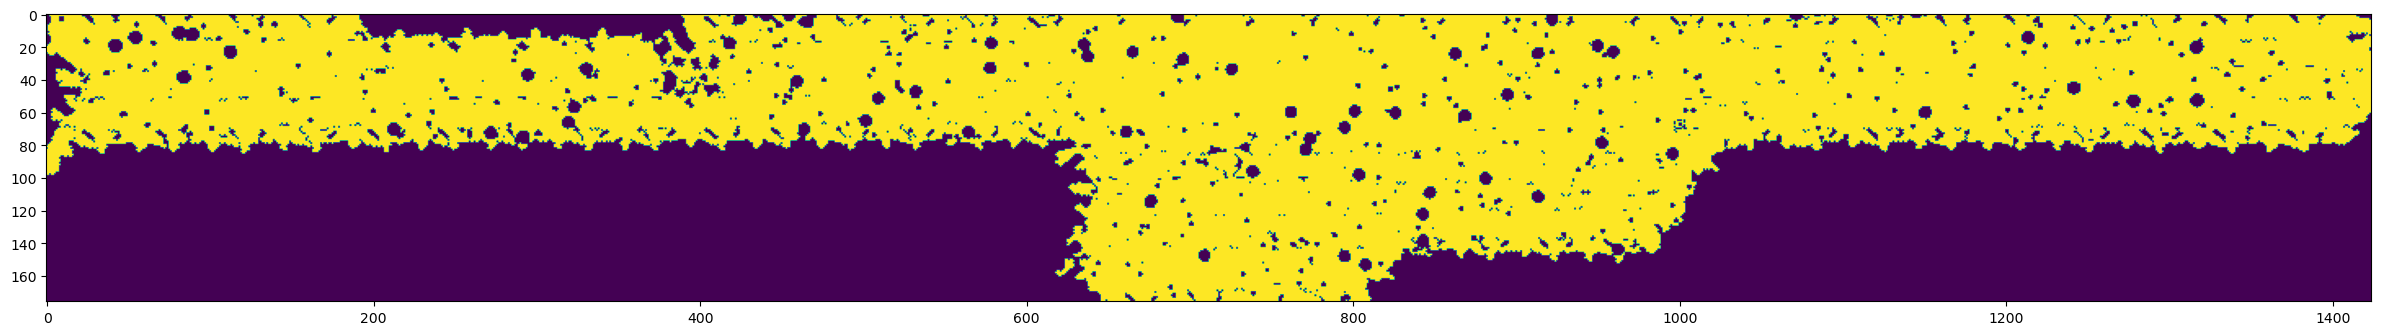

In [17]:
# mask
Visualization.plot_mask(mask=data_obj.mask)

noiseless training convergence map: The convergence maps show the projected matter density (including dark matter and ordinary matter) in the simulated universe, under the Born approximation. On large scales, we can see the matter forms web-like structures (cosmic web) in the universe. The dense regions in these maps, called dark matter halos, are the sites where galaxies form and reside.

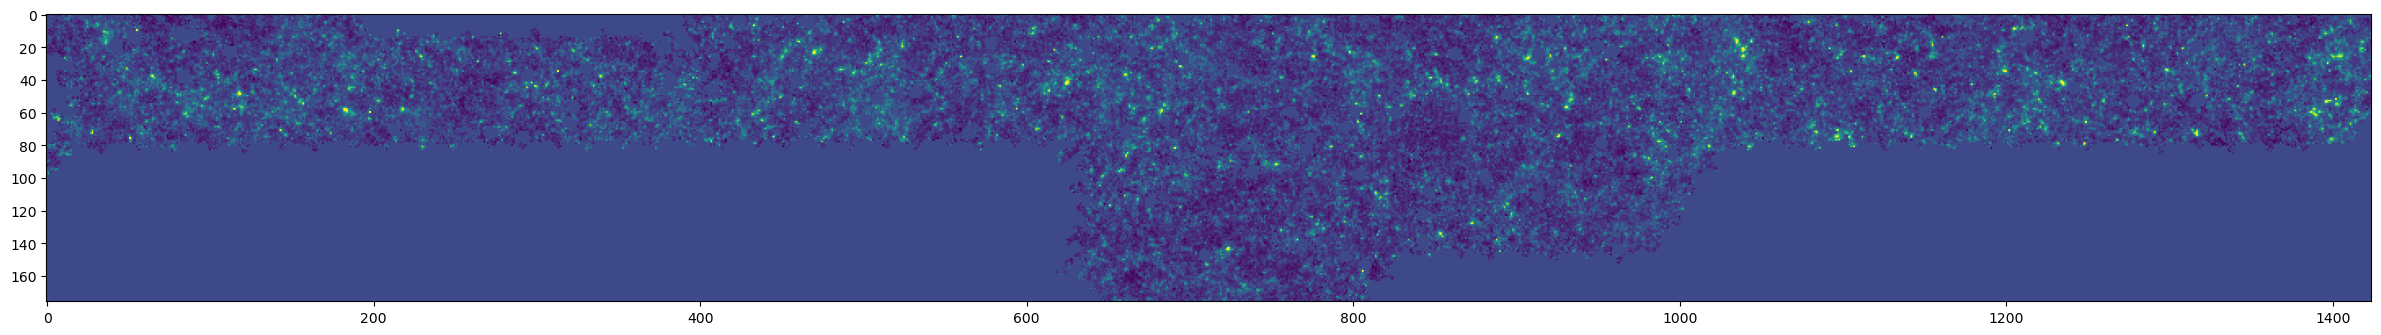

In [18]:
# noiseless training convergence map
Visualization.plot_noiseless_training_convergence_map(kappa=data_obj.kappa)

noisy training convergence map: We add Gaussian noise to the data. This mimics the observed data. During training the noise can be added on the fly with different realizations.

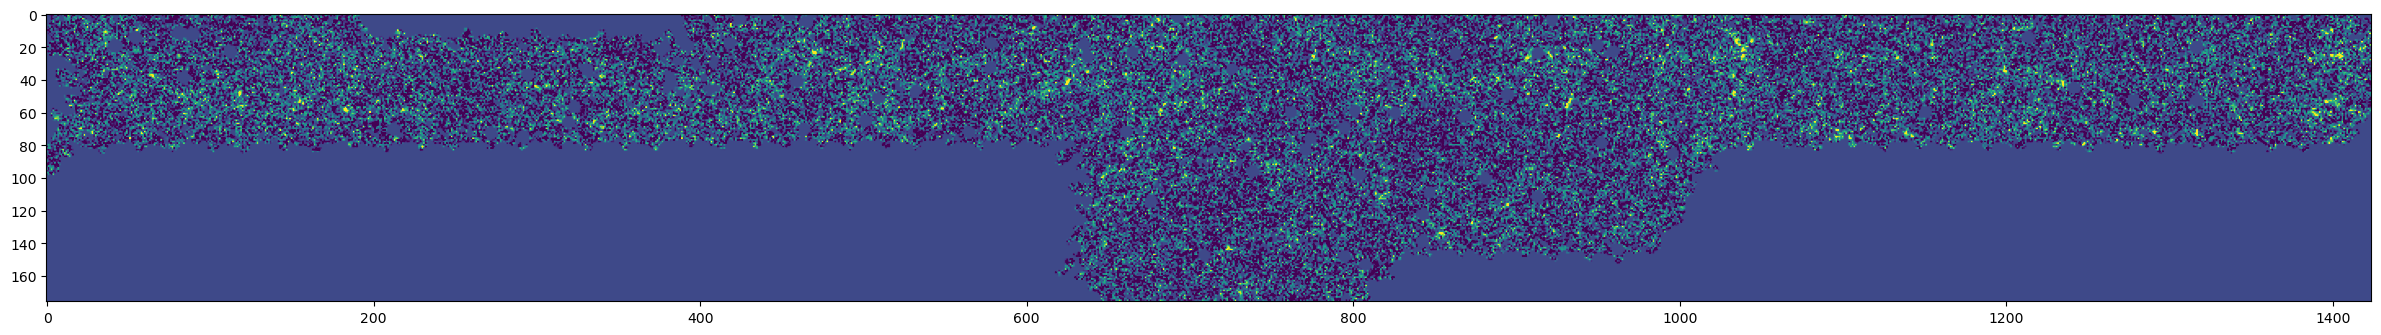

In [19]:
# noisy training convergence map
Visualization.plot_noisy_training_convergence_map(kappa=data_obj.kappa,
                                                  mask=data_obj.mask,
                                                  pixelsize_arcmin=data_obj.pixelsize_arcmin,
                                                  ng=data_obj.ng)

### Distribution of physical parameters

Distribution of cosmological parameters $\Omega_m$ and $S_8$. The density increases towards fiducial cosmology. Note that this distribution introduces a prior in the analysis. The test data cosmology follows the same distribution as the training data.

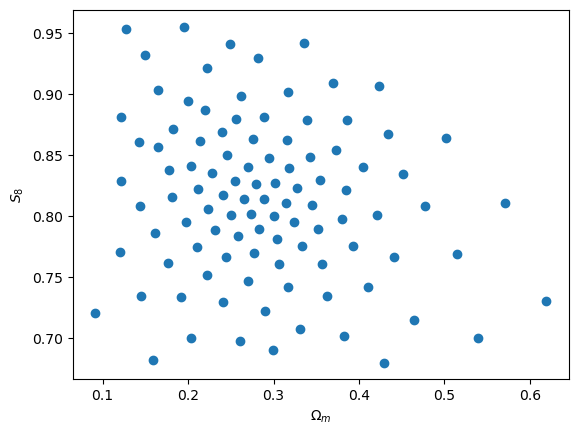

In [28]:
Visualization.plot_cosmological_parameters_OmegaM_S8(label=data_obj.viz_label)

Distribution of baryonic physics parameters. These are nuisance parameters and should be marginalized in the analysis. They follow a uniform distribution within the prior range $T_{\mathrm{AGN}} \in [7.2, 8.5]$, $f_0 \in [0, 0.0265]$

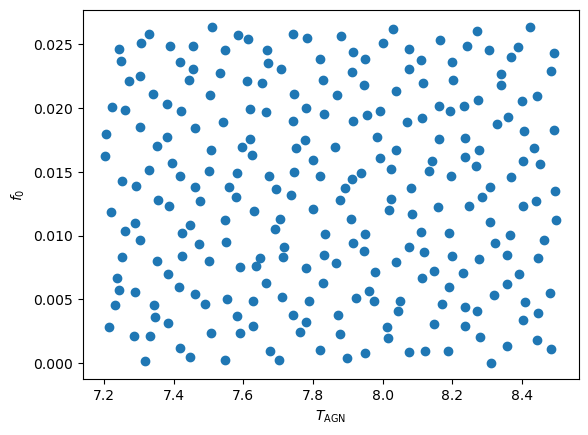

In [29]:
Visualization.plot_baryonic_physics_parameters(label=data_obj.viz_label)

Distribution of photometric redshift uncertainty parameters. This is a nuisance parameter and should be marginalized in the analysis. It follows a Gaussian distribution with mean 0 and std 0.022

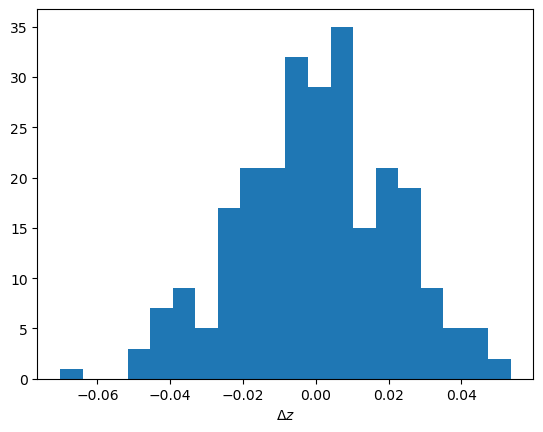

In [20]:
Visualization.plot_photometric_redshift_uncertainty_parameters(label=data_obj.viz_label)

# 4 - Training

In [14]:
# Define your path for saving the trained model
MODEL_SAVE_PATH = os.path.join(root_dir, "Phase2_starting_kit_AE_baseline.pth")

class Config:
    IMG_HEIGHT = data_obj.shape[0]
    IMG_WIDTH = data_obj.shape[1]

    # Training hyperparameters
    LATENT_DIM = 8
    BATCH_SIZE = 64
    EPOCHS = 15
    LEARNING_RATE = 2e-4
    WEIGHT_DECAY = 1e-4   # L2 regularization to prevent overfitting
    
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    MODEL_SAVE_PATH = MODEL_SAVE_PATH

In [15]:
class CosmologyDataset(Dataset):
    """
    Custom PyTorch Dataset
    """
    
    def __init__(self, data, labels=None,
                 transform=None,
                 label_transform=None):
        self.data = data
        self.labels = labels
        self.transform = transform
        self.label_transform = label_transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image = self.data[idx].astype(np.float32)   # Convert from float16 to float32
        if self.transform:
            image = self.transform(image) 
        if self.labels is not None:
            label = self.labels[idx].astype(np.float32)
            label = torch.from_numpy(label)
            if self.label_transform:
                label = self.label_transform(label)
            return image, label
        else:
            return image

In [16]:
# Compute the means and stds of the training images (for standardizing the data)

means = np.mean(X_train, dtype=np.float32)
stds = np.std(X_train, dtype=np.float32)

In [17]:
# Image standardization
from torchvision import transforms
transform = transforms.Compose([
    transforms.ToTensor(),     
    transforms.Normalize(mean=[means], std=[stds]),   
])
print(f"Image stats (from train set): Mean={means}, Std={stds}")

Image stats (from train set): Mean=-0.00012428639456629753, Std=0.020479273051023483


In [18]:
# # Load the configuration
config = Config()
print(f"Using device: {config.DEVICE}")

# Unsupervised datasets for AE (only images)
train_dataset_ae = CosmologyDataset(
    data=X_train,
    labels=None,         # Unsupervised learning: labels are not needed
    transform=transform
)

val_dataset_ae = CosmologyDataset(
    data=X_val,
    labels=None,         # Unsupervised learning: labels are not needed
    transform=transform
)

train_loader_ae = DataLoader(train_dataset_ae, batch_size=config.BATCH_SIZE, shuffle=True)
val_loader_ae   = DataLoader(val_dataset_ae, batch_size=config.BATCH_SIZE, shuffle=False)

Using device: cuda


In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Conv_AE(nn.Module):
    def __init__(self, img_height=config.IMG_HEIGHT, img_width=config.IMG_WIDTH, latent_dim=config.LATENT_DIM):
        super().__init__()
        self.img_height = img_height
        self.img_width = img_width
        self.latent_dim = latent_dim

        # Encoder
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=4, stride=2, padding=1),  
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=0.1),
            nn.Conv2d(16, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
        )

        # Compute flattened size after convs
        with torch.no_grad():
            dummy = torch.zeros(1, 1, img_height, img_width)
            h = self.encoder_conv(dummy)
            self.enc_out_channels = h.shape[1]
            self.enc_out_h = h.shape[2]
            self.enc_out_w = h.shape[3]
            self.flat_dim = self.enc_out_channels * self.enc_out_h * self.enc_out_w

        # Latent layers
        self.fc_mu = nn.Linear(self.flat_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flat_dim, latent_dim)

        # Decoder input layer
        self.fc_decode = nn.Linear(latent_dim, self.flat_dim)

        # Decoder
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),  
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(16, 1, kernel_size=4, stride=2, padding=1),    
        )

    def encode(self, x):
        h = self.encoder_conv(x)
        h_flat = h.view(h.size(0), -1)
        mu = self.fc_mu(h_flat)
        logvar = self.fc_logvar(h_flat)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.fc_decode(z)
        h = h.view(-1, self.enc_out_channels, self.enc_out_h, self.enc_out_w)
        x_recon = self.decoder_conv(h)
        return x_recon

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar

    def decode_from_mu(self, x):
        """Deterministic path: z = mu (no sampling)"""
        mu, logvar = self.encode(x)
        x_recon = self.decode(mu)
        return x_recon, mu, logvar

In [20]:
def vae_loss_component(x, x_recon, mu, logvar, beta=0):
    recon = F.mse_loss(x_recon, x, reduction='sum')
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    loss = (recon + beta * kl) / x.size(0)
    return loss, recon / x.size(0), kl / x.size(0)

In [ ]:
def train_ae(model, train_loader, val_loader, config):
    best_val_loss = float('inf')

    for epoch in range(config.EPOCHS):
        model.train()
        train_loss = 0.0
        train_recon = 0.0
        train_kl = 0.0
        n_train = 0
        pbar = tqdm(train_loader, total=len(train_loader), desc="Training")
        for batch in pbar:
            # batch is (images,) since labels=None
            if isinstance(batch, (list, tuple)):
                x = batch[0]
            else:
                x = batch

            x = x.to(config.DEVICE)  # shape [B, 1, 1424, 176]
            optimizer.zero_grad()
            x_recon, mu, logvar = model(x)
            loss, recon_loss, kl_loss = vae_loss_component(x, x_recon, mu, logvar)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * x.size(0)
            train_recon += recon_loss.item() * x.size(0)
            train_kl += kl_loss.item() * x.size(0)
            n_train += x.size(0)

        train_loss /= n_train
        train_recon /= n_train
        train_kl /= n_train

        # Validation
        model.eval()
        val_loss = 0.0
        val_recon = 0.0
        val_kl = 0.0
        n_val = 0
        pbar = tqdm(val_loader, total=len(val_loader), desc="Validating")
        with torch.no_grad():
            for batch in pbar:
                if isinstance(batch, (list, tuple)):
                    x = batch[0]
                else:
                    x = batch
                x = x.to(config.DEVICE)
                # x_recon, mu, logvar = model(x)
                x_recon, mu, logvar = model.decode_from_mu(x)
                loss, recon_loss, kl_loss = vae_loss_component(x, x_recon, mu, logvar)
                val_loss += loss.item() * x.size(0)
                val_recon += recon_loss.item() * x.size(0)
                val_kl += kl_loss.item() * x.size(0)
                n_val += x.size(0)
        val_loss /= n_val
        val_recon /= n_val
        val_kl /= n_val
        
        print(f"Epoch [{epoch+1}/{config.EPOCHS}] - "
              f"Train loss: {train_loss:.4f}/{train_recon:.4f}/{train_kl:.4f} - Val loss: {val_loss:.4f}/{val_recon:.4f}/{val_kl:.4f}")

        # Save best model on validation loss
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), config.MODEL_SAVE_PATH)
            print("  -> Saved best AE model")

    # load best weights into the same model and return it
    state_dict = torch.load(config.MODEL_SAVE_PATH, weights_only=True, map_location=config.DEVICE)
    model.load_state_dict(state_dict)
    return model

In [ ]:
# Initialize the AE model
model = Conv_AE(img_height=config.IMG_HEIGHT,
            img_width=config.IMG_WIDTH,
            latent_dim=config.LATENT_DIM).to(config.DEVICE)

Set `USE_PRETRAINED_MODEL = False` if you want to train a new model.\
Set `USE_PRETRAINED_MODEL = True` if you want to load a pretrained model.

In [28]:
USE_PRETRAINED_MODEL = False
# USE_PRETRAINED_MODEL = True

In [46]:
if not USE_PRETRAINED_MODEL:  
    # Train the model
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=config.LEARNING_RATE,
        weight_decay=config.WEIGHT_DECAY)
    
    model = train_ae(model, train_loader_ae, val_loader_ae, config)
    
else:
    # Check if the pretrained model exists
    if os.path.exists(config.MODEL_SAVE_PATH):
        # If the pretrained model exists, load the model
        model.load_state_dict(torch.load(config.MODEL_SAVE_PATH, weights_only=True))
    else:
        # If the pretrained model doesn't exist, show the warning message
        warning_msg = f"The path of pretrained model doesn't exist"
        warnings.warn(warning_msg)

Validating: 100%|██████████| 81/81 [00:04<00:00, 18.22it/s]


Epoch [1/15] - Train loss: 252851.7933/252851.7933/54.1971 - Val loss: 250895.5578/250895.5578/44.1422
  -> Saved best AE model


Validating: 100%|██████████| 81/81 [00:04<00:00, 18.65it/s]


Epoch [2/15] - Train loss: 250824.0540/250824.0540/50.0372 - Val loss: 250742.0016/250742.0016/43.0369
  -> Saved best AE model


Validating: 100%|██████████| 81/81 [00:04<00:00, 18.67it/s]


...

Epoch [13/15] - Train loss: 250599.9718/250599.9718/57.7352 - Val loss: 250596.7433/250596.7433/52.8815
  -> Saved best AE model


Validating: 100%|██████████| 81/81 [00:04<00:00, 18.37it/s]


Epoch [14/15] - Train loss: 250566.1656/250566.1656/62.7547 - Val loss: 250526.2032/250526.2032/52.5446
  -> Saved best AE model


Validating: 100%|██████████| 81/81 [00:04<00:00, 17.95it/s]


Epoch [15/15] - Train loss: 250402.9964/250402.9964/44.2599 - Val loss: 250236.3303/250236.3303/27.9285
  -> Saved best AE model


# 5 - Test statistic for OoD detection

In [44]:
# Compute recon-only scores
def compute_recon_scores(model, dataloader, device):
    model.eval()
    scores = []
    with torch.no_grad():
        for batch in dataloader:
            x = batch[0] if isinstance(batch, (list, tuple)) else batch
            x = x.to(device)
            # deterministic: z = mu
            x_recon, mu, logvar = model.decode_from_mu(x)
            recon = F.mse_loss(x_recon, x, reduction='none')
            recon = recon.view(recon.size(0), -1).sum(dim=1)  # per sample
            scores.append(recon.cpu().numpy())
    return np.concatenate(scores, axis=0)

In [ ]:
recon_scores_train = compute_recon_scores(model, train_loader_ae, config.DEVICE)
recon_scores_val   = compute_recon_scores(model, val_loader_ae,   config.DEVICE)

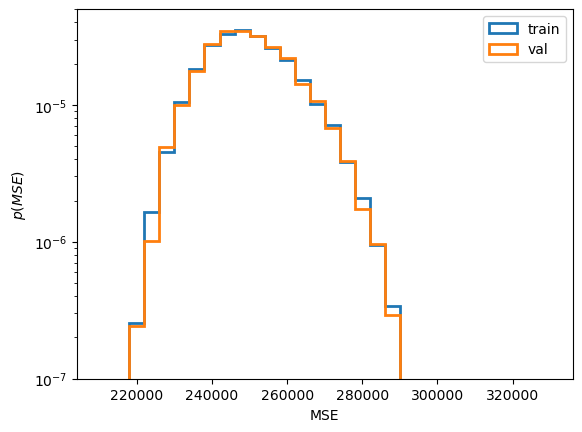

In [45]:
plt.hist(recon_scores_train, bins = 30, range = (210000, 330000), density = True, histtype='step', lw = 2, label = 'train')
plt.hist(recon_scores_val, bins = 30, range = (210000, 330000), density = True, histtype='step', lw = 2, label = 'val')
plt.legend()
plt.ylim(1e-7, 5e-5)
plt.yscale('log')
plt.xlabel(r'MSE')
plt.ylabel(r'$p(MSE)$')
plt.show()

In [46]:
test_dataset = CosmologyDataset(
    data=data_obj.kappa_test, 
    transform=transform
)

test_loader_ae = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

In [47]:
recon_scores_test = compute_recon_scores(model, test_loader_ae, config.DEVICE)

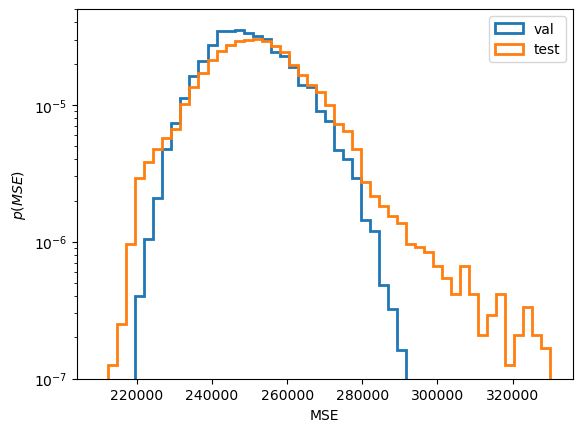

In [35]:
plt.hist(recon_scores_val, bins = 50, range = (210000, 330000), density = True, histtype='step', lw = 2, label = 'val')
plt.hist(recon_scores_test, bins = 50, range = (210000, 330000), density = True, histtype='step', lw = 2, label = 'test')
plt.legend()
plt.ylim(1e-7, 5e-5)
plt.yscale('log')
plt.xlabel(r'MSE')
plt.ylabel(r'$p(MSE)$')
plt.show()

### Define your OoD score
In this starting kit, we use the reconstrunction errors as the test statistic and treat the negative of $p$-values as the OoD score. We add a negative sign so that the score increases when the sample is more likely to be OoD.

In [26]:
## Define the test statistic
TS_InD = recon_scores_val
TS_test = recon_scores_test

## Negative of p-values as OoD scores
p_value_test = np.array([np.mean(chi2 < TS_InD) for chi2 in TS_test])
## A simple way to define the p-values for two-sided distribution
p_value_test = 2*np.min(np.array([p_value_test, 1-p_value_test]), axis=0)
ood_scores = -p_value_test

#### ⚠️ NOTE:
In this starting kit example, you may also directly submit the reconstruction errors of the test set as the OoD scores. However, keep in mind that for this method, the distribution of the reconstruction errors is two-sided, which means that OoD samples could be detected by either small or large reconstruction errors. To obtain the best ROC-AUC score, we recommend defining an OoD score that increases monotonically with the OoD probability.

# 7 - Prepare submission for Codabench

***

This section will save the model predictions `ood_scores` (an array with shape `(10000,)`, where `10000` is the number of test instances) as a dictionary in a JSON file `result.json`. Then it will compress `result.json` into a zip file that can be directly submitted to Codabench.

***

In [118]:
data = {"ood_scores": ood_scores.tolist()}
the_date = datetime.datetime.now().strftime("%y-%m-%d-%H-%M")
zip_file_name = 'Submission_' + the_date + '.zip'
zip_file = Utility.save_json_zip(
    submission_dir="submissions",
    json_file_name="result.json",
    zip_file_name=zip_file_name,
    data=data
)
print(f"Submission ZIP saved at: {zip_file}")

Submission ZIP saved at: submissions/Submission_26-03-10-17-27.zip
